# Begin

In [17]:
# @launchit.collected

In [18]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp
import sqlite3

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.utils.data import DataLoader

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, '.')) # @launchit.collect
from subproject import *
sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from image_utils import *
from model_registry import *
from torch_helpers import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect
from hp_utils import *
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement

# Init

In [19]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, mnist_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    model_group_uri=None,
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'subproject_path': '/home/misha/dev/mine/neurovision/15_transformer',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/15_transformer',
 'run_path': '/home/misha/dev/mine/neurovision/run/15_transformer',
 'self_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_predict_01.ipynb',
 'self_name': '15_predict_01',
 'subproject_name': '15_transformer',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [20]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN_MODEL = auto()

class LaunchGoalObj(namedtuple('LaunchGoalObj', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')):
    def matches(self, *g):
        if CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK:
            return True
            
        if g and isinstance(g[0], list):
            assert len(g) == 1
            return self.goal in g[0]

        return self.goal in g

LAUNCH_GOAL = LaunchGoalObj(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_GOAL = LAUNCH_GOAL._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_group_uri=CONFIG.model_group_uri)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_name=CONFIG.self_name)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_version=0)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG(f'LAUNCH_GOAL=\n{pprint.pformat(LAUNCH_GOAL._asdict(), sort_dicts=False)}', when=CONFIG.is_interactive)
LOG(f'LAUNCH_GOAL={LAUNCH_GOAL._asdict()}', when=not CONFIG.is_interactive)

LAUNCH_GOAL=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.15_transformer',
 'model_name': '15_predict_01',
 'model_version': 0,
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/15_transformer/15_predict_01.ipynb'}


# Hyperparameters

In [21]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    # dataset params
    db_fname: str = None
    sampler: str = None
    # model params
    embedding_size: int = None
    layers_count: int = None
    heads_count: int = None
    # training params
    batch_size: int = None
    epochs_count: int = None
    optimizer: str = None
    learn_rate: float | str = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42

In [22]:
@dataclass
class SamplerParams:
    class_name: str = None
    args: list = None
    kwargs: dict = None
    
def hp_parse_sampler(sampler):
    grammar = '''
        spec: random_sampler_spec
    
        # RANDOM SAMPLER
        random_sampler_spec: "RandomSampler" ( "(" arg_list_spec ")" )?
    
        arg_list_spec: (ARG_VALUE ("," ARG_VALUE)* ("," KWARG_NAME "=" KWARG_VALUE)*)? (KWARG_NAME "=" KWARG_VALUE ("," KWARG_NAME "=" KWARG_VALUE)*)?
        ARG_VALUE: NUMBER
        KWARG_NAME: IDENTIFIER
        KWARG_VALUE: NUMBER
        IDENTIFIER: LETTER (LETTER|DIGIT|"_")*
        
        %import common.LETTER
        %import common.DIGIT
        %import common.NUMBER
        %import common.INT
        %import common.WS
        %ignore WS
    '''
    lark_parser = lark.Lark(grammar, start='spec')
    tree = lark_parser.parse(sampler)

    if t := list(tree.find_data('random_sampler_spec')):
        args, kwargs = parse_arg_list(t[0])
        return SamplerParams(class_name='RandomSampler', args=args, kwargs=kwargs)
    else:
        assert False, f'Unsupported {sampler=}'    

In [23]:
hp_parse_sampler('RandomSampler(123, a=1, b=2)')

SamplerParams(class_name='RandomSampler', args=[123], kwargs={'a': 1, 'b': 2})

# Launch

## new_model_registry

In [24]:
def new_model_registry(is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_GOAL.model_group_uri)

## new_summary_writer

In [25]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [26]:
optuna_trial = optuna_multiprocessing.get_trial()
optuna_trial_subdir_name = ''

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_GOAL.model_version)
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    optuna_trial_subdir_name = f'opt_{study_serial}'
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

model_registry = new_model_registry()
model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, CONFIG.self_fname, replace=True)
    
meta = dict(
    optuna_trial_number=getattr(optuna_trial, 'number', None),
    hypers=HP._asdict(), 
    config=CONFIG._asdict(), 
)

with io.StringIO() as b:
    json.dump(meta, b)
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = LAUNCH_GOAL.model_name
summary_log_dir = os.path.join(summary_log_dir, optuna_trial_subdir_name) if optuna_trial_subdir_name != '' else summary_log_dir 
summary_log_dir = os.path.join(summary_log_dir, str(LAUNCH_GOAL.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=42
Tensorboard run=15_predict_01/0


<Mock name='mock.add_text()' id='139123552705840'>

# Dataset

## Configure

In [321]:
HP.db_fname = 'encodings_5_128.db'

## get_db_con

In [322]:
def get_db_con(hp=None):
    hp = LangUtils.coalesce(hp, HP)
    assert hp.db_fname, f'Uninitialized {hp.db_fname=}'
    return sqlite3.connect(f'file:{os.path.join(CONFIG.private_data_path, hp.db_fname)}?mode=ro', uri=True)

## load_image_encoding

In [323]:
def load_image_encoding(image_ind, db_con):
    return pd.read_sql('SELECT e.pos_token_ind, e.vocab_token_ind, e.bfr, pt.i, pt.j, pt.i2, pt.j2, pt.center_i, pt.center_j ' + 
                       'FROM encodings e, vocab_tokens vt, pos_tokens pt ' + 
                       'WHERE e.pos_token_ind=pt.token_ind AND e.vocab_token_ind=vt.token_ind AND e.image_ind=:image_ind', con=db_con, params=dict(image_ind=image_ind))

# Samplers

## BaseRandomSampler

In [389]:
class BaseRandomSampler:
    def __init__(self, image_size, patch_size, max_seq_length, max_overlap):
        self.image_shape = (image_size, image_size)
        self.patch_area = patch_size ** 2
        self.max_seq_length = max_seq_length
        assert 0 < max_overlap <= 1, max_overlap
        self.max_overlap = max_overlap

    def __call__(self, df_encoding):
        seq = []
        busy_map = np.zeros(self.image_shape, dtype='b')
        visited_row_inds = set()
        cycles_count = 0

        while len(seq) < self.max_seq_length:
            cycles_count += 1
            row_ind = RNG.choice(len(df_encoding))

            if row_ind in visited_row_inds:
                continue

            enc_row = next(df_encoding.iloc[[row_ind]].itertuples())
            overlap = busy_map[enc_row.i:enc_row.i2,enc_row.j:enc_row.j2].sum() / self.patch_area

            if overlap > self.max_overlap:
                continue

            if not self.is_bfr_ok(enc_row.bfr):
                continue
                
            seq.append((enc_row.pos_token_ind, enc_row.vocab_token_ind))
            busy_map[enc_row.i:enc_row.i2,enc_row.j:enc_row.j2] = 1
            visited_row_inds.add(row_ind)
        
        return np.array(seq), cycles_count

## LinearRandomSampler

In [390]:
class LinearRandomSampler(BaseRandomSampler):
    def __init__(self, image_size, patch_size, max_seq_length, max_overlap, b):
        super().__init__(image_size, patch_size, max_seq_length, max_overlap)
        # build y=kx+b for line which passes through point (1,1)
        self.k = 1 - b
        self.b = b

    def is_bfr_ok(self, bfr):
        threshold = self.k * bfr + self.b
        return RNG.uniform() < threshold

## SigmoidRandomSampler

In [391]:
class SigmoidRandomSampler(BaseRandomSampler):
    def __init__(self, image_size, patch_size, max_seq_length, max_overlap, k, b):
        super().__init__(image_size, patch_size, max_seq_length, max_overlap)
        self.k = k
        self.b = b

    def is_bfr_ok(self, bfr):
        threshold = 1 / (1 + np.exp(self.k * (-bfr + self.b)))
        return RNG.uniform() < threshold

## SpiralSampler

In [398]:
class SpiralSampler:
    def __init__(self, image_size, patch_size, max_seq_length, direction, stride):
        self.image_size = image_size
        self.patch_size = patch_size
        
        match direction:
            case 'cw': self.steps = (-stride, +stride, +stride, -stride)
            case 'ccw': self.steps = (-stride, -stride, +stride, +stride)
            case _: assert False, f'Unsupported {direction=}'
        
        self.max_seq_length = max_seq_length

    def __call__(self, df_encoding):
        df_non_empty_encoding = df_encoding[df_encoding.bfr > 0]
        start_i, start_j = int(df_non_empty_encoding.center_i.mean()), int(df_non_empty_encoding.center_j.mean())
        d = dict(map(lambda row: ((row.center_i, row.center_j), row),  df_encoding.itertuples()))
        seq = []
        cycles_count = 0
        
        for i, j, step_size in self.spiral_generator(start_i, start_j):
            # print(i, j, d[(i, j)].i, d[(i, j)].i2, d[(i, j)].j, d[(i, j)].j2)
            cycles_count += 1
            
            if r := LangUtils.coalesce(d.get((i, j)), False):
                seq.append((r.pos_token_ind, r.vocab_token_ind))
    
                if len(seq) >= self.max_seq_length:
                    break
                
            if step_size > self.image_size * 2:
                break

        return np.array(seq), cycles_count
        
    def spiral_generator(self, i, j):
        step_size = 1
        yield (i, j, step_size)
        
        while True:
            # 1. Move Up (i decreases)
            for _ in range(step_size):
                # i -= self.patch_size
                i += self.steps[0]
                yield (i, j, step_size)
            
            # 2. CW: Move Right (j increases) 
            # 2. CCW: Move Left (j decreases) 
            for _ in range(step_size):
                # j += self.patch_size
                j += self.steps[1]
                yield (i, j, step_size)
            
            step_size += 1 # Increase step length
            
            # 3. Move Down (i increases)
            for _ in range(step_size):
                # i += self.patch_size
                i += self.steps[2]
                yield (i, j, step_size)
                
            # 4. CW: Move Left (j decreases)
            # 4. CCW: Move Right (j increases)
            for _ in range(step_size):
                # j -= self.patch_size
                j += self.steps[3]
                yield (i, j, step_size)
                
            step_size += 1 

## ZigzagSampler

In [399]:
class ZigzagSampler:
    def __init__(self, image_size, patch_size, max_seq_length, stride):
        self.image_size = image_size
        self.patch_size = patch_size
        self.max_seq_length = max_seq_length
        self.stride = stride

    def __call__(self, df_encoding):
        df_non_empty_encoding = df_encoding[df_encoding.bfr > 0]
        min_i, min_j = int(df_non_empty_encoding.i.min()), int(df_non_empty_encoding.j.min())
        max_i, max_j = int(df_non_empty_encoding.i.max()), int(df_non_empty_encoding.j.max())
        d = dict(map(lambda row: ((row.i, row.j), row),  df_encoding.itertuples()))
        seq = []
        cycles_count = 0
        ij_list = []

        for i in range(min_i, max_i + 1, self.stride):
            for j in range(min_j, max_j + 1, self.stride):
                ij_list.append((i,j))

        for ij in ij_list:
            cycles_count += 1
            r = d[ij]
            seq.append((r.pos_token_ind, r.vocab_token_ind))

            if len(seq) >= self.max_seq_length:
                break

        return np.array(seq), cycles_count

## Demo

15 15


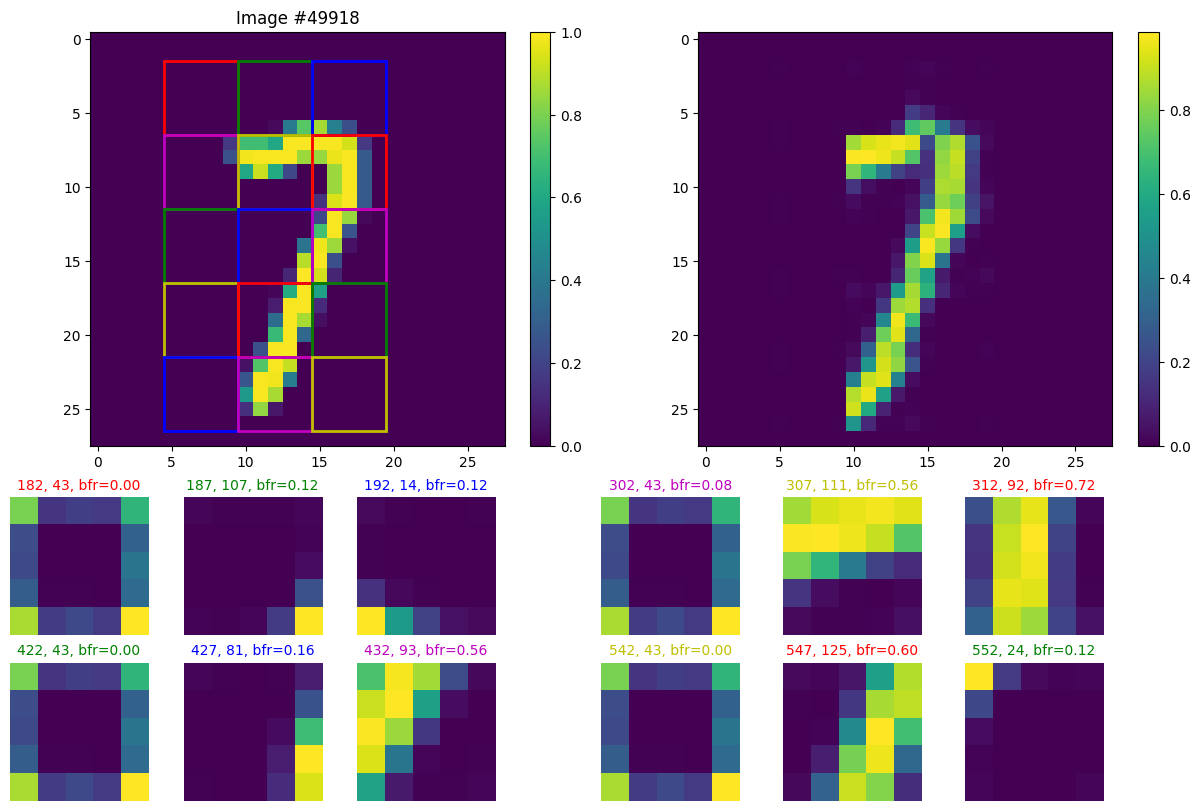

In [401]:
with get_db_con() as db_con:
    meta = load_meta(db_con)
    df_image_inds = pd.read_sql(f'SELECT DISTINCT(image_ind) FROM encodings', con=db_con)
    image_ind = int(RNG.choice(df_image_inds.image_ind))
    # image_ind = 36947
    # image_ind = 16346 # thin 6 which shows poor reconstruction
    df_vocab_tokens = load_vocab_tokens(db_con)
    df_encoding = load_image_encoding(image_ind, db_con)

    # sampler = LinearRandomSampler(meta.image_size, meta.patch_size, max_seq_length=meta.patch_size**2, max_overlap=0.5, b=0.2)
    # sampler = SigmoidRandomSampler(meta.image_size, meta.patch_size, max_seq_length=meta.patch_size**2, max_overlap=0.5, k=15, b=0.4)
    # sampler = SpiralSampler(meta.image_size, meta.patch_size, max_seq_length=meta.patch_size**2, direction='cw', stride=meta.patch_size)
    sampler = ZigzagSampler(meta.image_size, meta.patch_size, max_seq_length=meta.patch_size**2, stride=meta.patch_size)
    seq, cycles_count = sampler(df_encoding)
    print(cycles_count, len(seq))
    seq = seq.reshape(-1, 2)
    
    fig, axd = plt.subplot_mosaic(
        [
            ['A', 'A', 'A', 'B', 'B', 'B'],
            ['A', 'A', 'A', 'B', 'B', 'B'],
            ['A', 'A', 'A', 'B', 'B', 'B'],
            ['C', 'D', 'E', 'F', 'G', 'H'],
            ['I', 'J', 'K', 'L', 'M', 'N'],
        ], 
        layout="constrained"
    )
    fig.set_figwidth(12)
    fig.set_figheight(8)
    image = load_image(image_ind, db_con)
    axd['A'].set_title(f'Image #{image_ind}')
    im = axd['A'].imshow(image)
    fig.colorbar(im, ax=axd['A'])
    b_image = np.zeros((meta.image_size, meta.image_size))

    for ind, (pos_token_ind, vocab_token_ind) in enumerate(seq):
        color = 'rgbmy'[ind % 5]
        df_row = df_encoding[df_encoding.pos_token_ind == pos_token_ind]
        assert len(df_row) == 1
        df_row = next(df_row.itertuples())
        rect = pltpatches.Rectangle((df_row.j-0.5, df_row.i-0.5), meta.patch_size, meta.patch_size, linewidth=2, edgecolor=color, facecolor='none')
        axd['A'].add_patch(rect)
        df_vocab_row = df_vocab_tokens[df_vocab_tokens.token_ind == df_row.vocab_token_ind].iloc[0]
        with BytesIO(df_vocab_row.data) as b: vocab_item = np.load(b)
        b_image[df_row.i:df_row.i2,df_row.j:df_row.j2] = ArrayUtils.v2sm(vocab_item)
    
    im = axd['B'].imshow(b_image)
    fig.colorbar(im, ax=axd['B'])
    
    for ind, ((pos_token_ind, vocab_token_ind), ax_name) in enumerate(zip(seq, 'CDEFGHIJKLMN')):
        color = 'rgbmy'[ind % 5]
        df_row = df_encoding[df_encoding.pos_token_ind == pos_token_ind]
        assert len(df_row) == 1
        df_row = next(df_row.itertuples())
        df_vocab_row = df_vocab_tokens[df_vocab_tokens.token_ind == df_row.vocab_token_ind].iloc[0]
        with BytesIO(df_vocab_row.data) as b: vocab_item = np.load(b)
        ax = axd[ax_name]
        title = '\n'.join((
            f'{df_row.pos_token_ind}, {df_row.vocab_token_ind}, bfr={df_row.bfr:.2f}',
        ))
        ax.set_title(title, c=color, fontdict=dict(fontsize=10))
        ax.imshow(ArrayUtils.v2sm(vocab_item))
        ax.set_axis_off()

# TRAIN_MODEL

## Configure

## Create

## Train

## Save

## Save optuna trial result

# LaunchIt!

## TRAIN_MODEL

In [31]:
# @launchit.disable
launchit_t0 = time.time()

In [36]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.TRAIN_MODEL.value,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=11
Creating /home/misha/dev/mine/neurovision/15_transformer/15_vocab_02-launch11.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/15_transformer/15_vocab_02-launch11.ipynb"


## Optuna (model selection)

### Templates

In [45]:
# @launchit.disable
# @launchit.collect_2
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    
    match study_serial:
        case 1:
            HP = Hyperparameters()
            HP.random_seed = 42
            assert False
        case _:
            assert False, f'Unsupported {study_serial=}'            

### Unleash

In [ ]:
# @launchit.disable
def get_optimize_directions(lg):
    match lg:
        case LaunchGoal.TRAIN_MODEL:
            return ['minimize']
        case _:
            assert False, f'Unsupported {lg=}'

lg = LaunchGoal.TRAIN_MODEL
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=lg.value,
)
study_serial = 1
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_{study_serial}'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[],
    run_path=CONFIG.run_path,
    study_serial=study_serial,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(lg),
)
rop_tasks = [rop_task] * 1
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=4, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")